This notebook was created by Donyl Alcantara

# Network Topology of Reddit

### Overview

Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since the 1500s, when an unknown printer took a galley of type and scrambled it to make a type specimen book. It has survived not only five centuries, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised in the 1960s with the release of Letraset sheets containing Lorem Ipsum passages, and more recently with desktop publishing software like Aldus PageMaker including versions of Lorem Ipsum.



## Section 1: Environment Configuration

#### 1.1 Environment Setup

In [1]:
import pandas as pd
import re
import zstandard as zstd
import io
import orjson
from collections import defaultdict
import json
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import csv
import polars as pl
import os
import gdown
import numpy as np
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF
from pathlib import Path
import powerlaw
import mapclassify

#### 1.2 Import `user_subreddit_interactions` from `analytics`

In [2]:
df_all = pl.scan_parquet('analytics/user_subreddit_interactions.parquet').collect()
df_all 

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""Shatter_starx""","""pcmasterrace""",0,22,22
"""geeriveting""","""reddeadredemption""",0,1,1
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BlackAbsol44""","""pcmasterrace""",1,0,1
…,…,…,…,…
"""spoonyF0rky01""","""news""",0,6,6
"""outsidewrld1""","""dating_advice""",1,0,1
"""SweetSoberCaroline""","""askreddit""",0,1,1


## Section 2: Data Pre-Processing/Exploratory Data Analysis

According to [Jakobsen (2022)](https://blog.bruun.dev/exploring-reddit-community-relations-with-graphs-and-neo4j/), due to the existence of significant noise, including the possibility of repeated interactions, specifically because of 'bot users,' we initially do the following: 

- Normalize subreddit names (done in 00)
- Filter self-referential interactions 
- Remove interactions made by top 2% users
- Remove single-interaction subreddit pairs
- Merge interactions between subreddit pairs


#### 2.1 User Activity Aggregation

In [3]:
# total interaction per author 

df_author_interaction = df_all.group_by('author').agg(
    pl.col("interaction_count").sum().alias('interaction_per_user')).sort(
    'interaction_per_user', descending=True) # convert into eager df

# create rank col
df_author_interaction = df_author_interaction.with_columns(pl.arange(
    1, df_author_interaction.height + 1).alias("rank")) # height = number of rows, width = number of cols

df_author_interaction.head(20)

author,interaction_per_user,rank
str,i64,i64
"""donut-bot""",163298,1
"""TipOfTheirTongue""",162697,2
"""VisualMod""",100202,3
"""MinecraftModBot""",89755,4
"""MrPuma86""",65225,5
…,…,…
"""Sky-876""",20904,16
"""bvandepol""",20343,17
"""AskWomen-ModTeam""",20105,18


In [ ]:
# top 20 

# bar graph
plt.figure(figsize=(10, 6))
plt.bar(df_author_interaction['author'].head(20),
        df_author_interaction['interaction_per_user'].head(20),
        edgecolor='black')
plt.title("Top 20 Users by Interaction Count (Comments & Posts)")
plt.xlabel("Author")
plt.ylabel("Frequency")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

In [5]:
# 1. Use the truncated dataset you already have (final_auti or df_author_interaction)
# Based on your error, the column is 'interaction_per_user'
# We skip the heavy group_by because the data is already per-author.

print("Generating frequency distribution")
dist = (
    df_author_interaction.group_by("interaction_per_user")
    .len()
    .rename({"len": "user_count"})
    .sort("interaction_per_user")
)

# 2. The Head-Tail Breaks Algorithm (Mathematical Backing)
def find_head_tail_break(data):
    # 'interaction_per_user' is our value (X)
    # 'user_count' is our frequency (Y)
    current_data = data
    iteration = 1
    
    while True:
        # Calculate Weighted Mean: (Value * Frequency) / Total Frequency
        total_val = (current_data["interaction_per_user"] * current_data["user_count"]).sum()
        total_freq = current_data["user_count"].sum()
        mu = total_val / total_freq
        
        # The 'Head' are those strictly above the mean
        head = current_data.filter(pl.col("interaction_per_user") > mu)
        
        # Calculate what percentage of users remain in the head
        head_percentage = head["user_count"].sum() / total_freq
        
        print(f"Iteration {iteration}: Mean = {mu:.2f}, Head % = {head_percentage:.2%}")
        
        # THE RULE: If the head is no longer a small minority (<40%), 
        # or we run out of data, the current mean is our natural threshold.
        if head_percentage > 0.40 or head.height == 0:
            final_threshold = round(mu)
            print(f"\n--- RESULT ---")
            print(f"Natural Mathematical Threshold: {final_threshold}")
            return final_threshold
            
        current_data = head
        iteration += 1

# Execute
final_threshold = find_head_tail_break(dist)

Generating frequency distribution
Iteration 1: Mean = 19.95, Head % = 14.98%
Iteration 2: Mean = 111.74, Head % = 23.32%
Iteration 3: Mean = 329.81, Head % = 27.19%
Iteration 4: Mean = 719.13, Head % = 28.44%
Iteration 5: Mean = 1348.18, Head % = 28.56%
Iteration 6: Mean = 2353.19, Head % = 26.95%
Iteration 7: Mean = 4103.98, Head % = 25.09%
Iteration 8: Mean = 7542.95, Head % = 22.38%
Iteration 9: Mean = 15659.53, Head % = 17.95%
Iteration 10: Mean = 39373.11, Head % = 21.43%
Iteration 11: Mean = 104585.83, Head % = 33.33%
Iteration 12: Mean = 162997.50, Head % = 50.00%

--- RESULT ---
Natural Mathematical Threshold: 162998


#### 2.2 Rank-Frequency Profiling

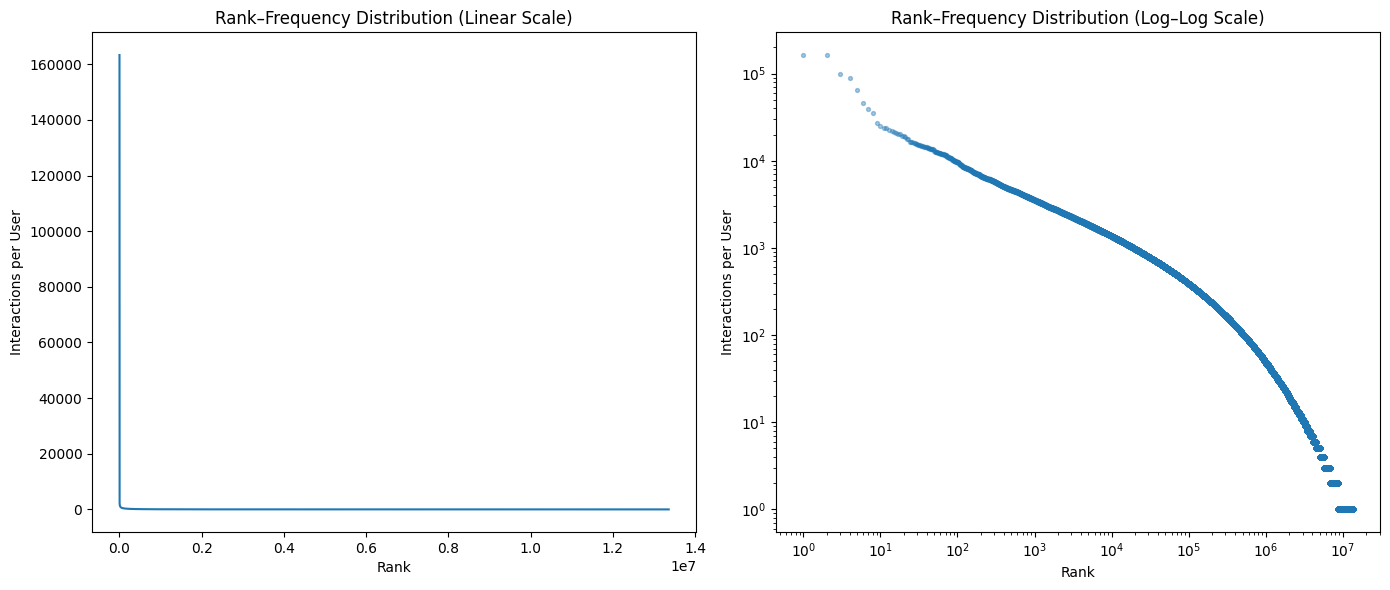

In [6]:
# visualize the long-tail dist with and without scaling
# convert polars series to numpy
x = df_author_interaction['rank'].to_numpy()
y = df_author_interaction['interaction_per_user'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Linear scale
axes[0].plot(x, y)
axes[0].set_title("Rank–Frequency Distribution (Linear Scale)")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Interactions per User")

# Log–Log scale
axes[1].scatter(x, y, alpha=0.4, s=8, color='#1f77b4')
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Rank–Frequency Distribution (Log–Log Scale)")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Interactions per User")

plt.tight_layout()
plt.show()

#### 2.3 Outlier/Noise Detection 

#### Log Interquartile Range (IQR)

In [7]:
data = df_author_interaction["interaction_per_user"].to_numpy()
log_data = np.log1p(data)

Q1 = np.percentile(log_data, 25)
Q3 = np.percentile(log_data, 75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = data[log_data > upper_bound]

print(f"Outlier threshold: {np.expm1(upper_bound):.0f}")

Outlier threshold: 111


#### Contribution Share

The distribution of user activity exhibits a pronounced long-tail. We observe a high concentration of activity among a small subset of users: the top 2% of contributors account for approximately 47% of all interactions. This extreme inequality suggests that a small number of highly active users disproportionately shape the interaction network. To mitigate this bias and reduce potential noise from automated or hyperactive accounts, we remove users whose interaction counts fall within the top 2% of the distribution.

In [8]:
# sort descending
df_cs = df_author_interaction.sort("interaction_per_user", descending=True)
total_interactions = df_cs["interaction_per_user"].sum()

# iterate over top 1 to 20%
for pct in range(1, 21):
    n_top = int(df_cs.height * (pct/100))
    top_users = df_cs.head(n_top)
    share = top_users["interaction_per_user"].sum() / total_interactions
    print(f"Top {pct}% users: {n_top}, Contribution share: {share:.2f}")

Top 1% users: 133614, Contribution share: 0.35
Top 2% users: 267228, Contribution share: 0.47
Top 3% users: 400842, Contribution share: 0.55
Top 4% users: 534456, Contribution share: 0.60
Top 5% users: 668070, Contribution share: 0.65
Top 6% users: 801684, Contribution share: 0.68
Top 7% users: 935298, Contribution share: 0.71
Top 8% users: 1068912, Contribution share: 0.74
Top 9% users: 1202526, Contribution share: 0.76
Top 10% users: 1336140, Contribution share: 0.77
Top 11% users: 1469754, Contribution share: 0.79
Top 12% users: 1603368, Contribution share: 0.81
Top 13% users: 1736983, Contribution share: 0.82
Top 14% users: 1870597, Contribution share: 0.83
Top 15% users: 2004211, Contribution share: 0.84
Top 16% users: 2137825, Contribution share: 0.85
Top 17% users: 2271439, Contribution share: 0.86
Top 18% users: 2405053, Contribution share: 0.86
Top 19% users: 2538667, Contribution share: 0.87
Top 20% users: 2672281, Contribution share: 0.88


#### Lorenz Curve and Gini Coefficient

The Gini coefficient of user interactions is 0.83, indicating extreme inequality. The top 2% of users generate 47% of all interactions, confirming that a small subset of highly active users dominates the network. To reduce the influence of these extreme contributors, we remove users within the top 2% of the distribution.

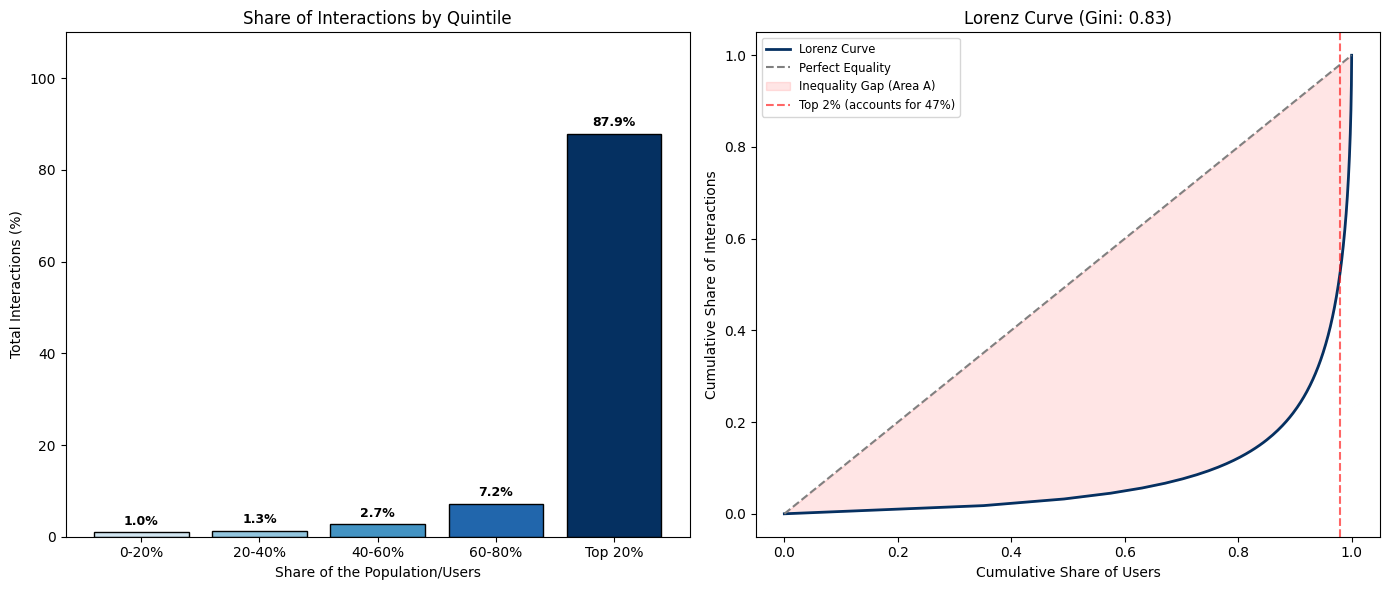

In [9]:
y_sorted = np.sort(df_author_interaction["interaction_per_user"].to_numpy())
total_val = y_sorted.sum()
n_users = len(y_sorted)

# lorenz data
cum_users = np.arange(1, n_users + 1) / n_users
cum_activity = np.cumsum(y_sorted) / total_val
gini = 1 - 2 * np.sum((cum_activity[1:] + cum_activity[:-1]) * np.diff(cum_users) / 2)

# quintile data
groups = np.array_split(y_sorted, 5)
shares = [(g.sum() / total_val) * 100 for g in groups]
quintile_labels = ['0-20%', '20-40%', '40-60%', '60-80%', 'Top 20%']
colors = ['#d1e5f0', '#92c5de', '#4393c3', '#2166ac', '#053061']

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Quintile Bar Chart
bars = ax1.bar(quintile_labels, shares, color=colors, edgecolor='black')
ax1.set_title('Share of Interactions by Quintile')
ax1.set_ylabel('Total Interactions (%)')
ax1.set_xlabel('Share of the Population/Users')
ax1.set_ylim(0, 110)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Lorenz Curve
ax2.plot(cum_users, cum_activity, label='Lorenz Curve', color='#053061', linewidth=2)
ax2.plot([0,1], [0,1], linestyle='--', color='grey', label='Perfect Equality')
ax2.fill_between(cum_users, cum_activity, cum_users, color='red', alpha=0.1, label='Inequality Gap (Area A)')

# threshold 
ax2.axvline(cum_users[int(len(y_sorted) * 0.98)], linestyle='--', color='r', alpha=0.6, label=f'Top 2% (accounts for {(1-cum_activity[int(len(y_sorted) * 0.98)])*100:.0f}%)')
ax2.set_title(f'Lorenz Curve (Gini: {gini:.2f})')
ax2.set_xlabel('Cumulative Share of Users')
ax2.set_ylabel('Cumulative Share of Interactions')
ax2.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

#### 98th Percentile vs. Power-law xmin

Calculating best minimal value for power law fit


Fitting xmin: 100%|█████████████████████████| 4101/4101 [06:29<00:00, 10.52it/s]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


Top 2% threshold: 185.00
Power-law xmin: 622.00


/var/folders/_g/nz39y46d1l93yjn3vj6_jd100000gn/T/ipykernel_13585/1656712637.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


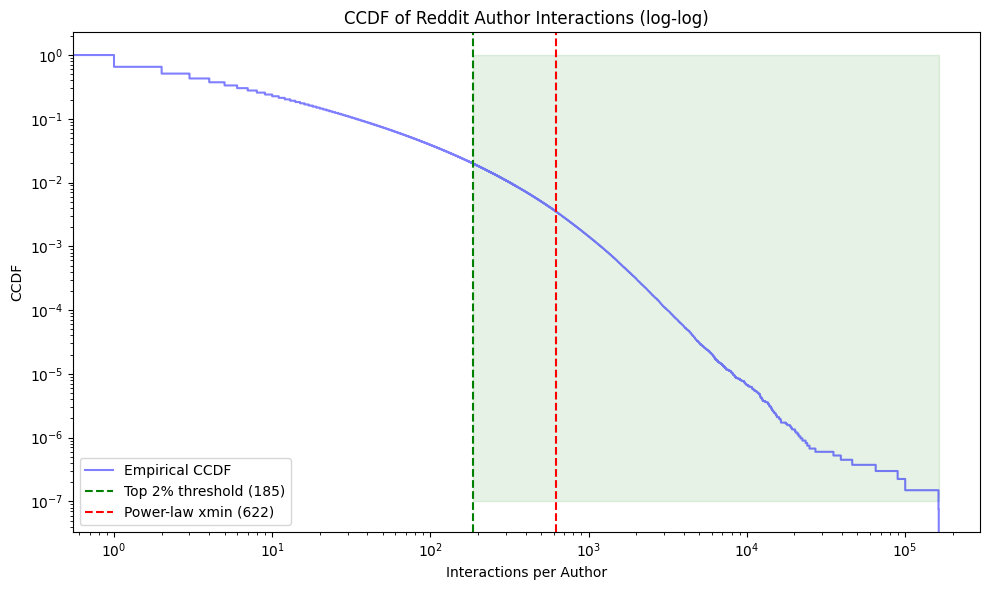

In [13]:
# Data
data = df_author_interaction["interaction_per_user"].to_numpy()

# Compute thresholds
# 98th percentile
threshold_2pct = np.percentile(data, 98)

# Power law params
fit = powerlaw.Fit(data) 
alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print(f"Top 2% threshold: {threshold_2pct:.2f}")
print(f"Power-law xmin: {xmin:.2f}")

# Compute ECDF and CCDF
ecdf = ECDF(data)
ccdf = 1 - ecdf.y  # CCDF = 1 - CDF

# plot CCDF
plt.figure(figsize=(10,6))
plt.step(ecdf.x, ccdf, where='post', color='blue', alpha=0.5, label='Empirical CCDF')
plt.xscale('log')  # log-log scale
plt.yscale('log')

# threshold lines
plt.axvline(threshold_2pct, color='green', linestyle='--',  
            label=f'Top 2% threshold ({threshold_2pct:.0f})')
plt.axvline(xmin, color='red', linestyle='--',
            label=f'Power-law xmin ({xmin:.0f})')

# shade the top 2%
plt.fill_betweenx(y=[1e-7, 1], x1=threshold_2pct, x2=ecdf.x.max(),
                  color='green', alpha=0.1)

# labels
plt.xlabel("Interactions per Author")
plt.ylabel("CCDF")
plt.title("CCDF of Reddit Author Interactions (log-log)")
# plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Compare Power Law vs. Log-normal
R, p = fit.distribution_compare('power_law', 'lognormal')

print(f"Loglikelihood ratio (R): {R:.2f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    if R > 0:
        print("Conclusion: Reject H0. Power Law is a significantly better fit.")
    else:
        print("Conclusion: Reject H0. Log-normal is a significantly better fit.")
else:
    print("Conclusion: Fail to reject H0. Neither distribution is significantly better.")

Loglikelihood ratio (R): -198.21
p-value: 0.0000
Conclusion: Reject H0. Log-normal is a significantly better fit.


Log-normal parameters: mu=3.15, sigma=1.45


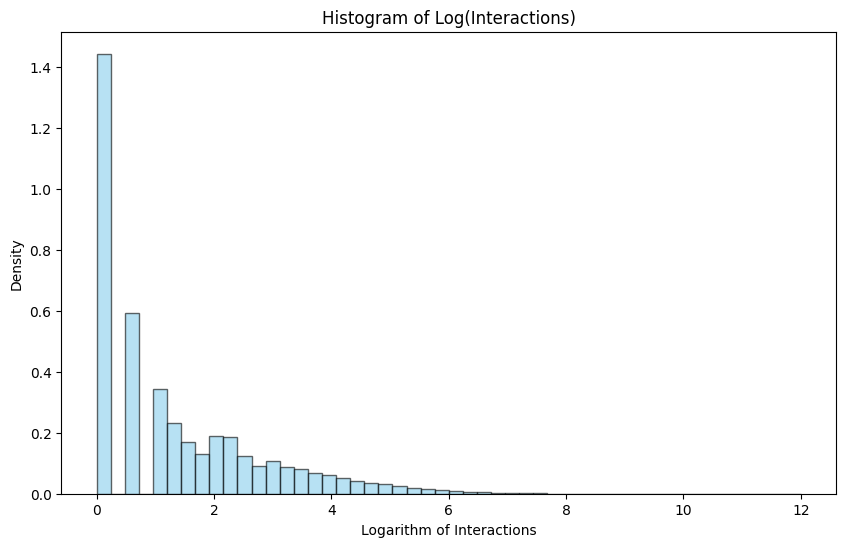

In [15]:
# Extract parameters from the fit
mu = fit.lognormal.mu
sigma = fit.lognormal.sigma

print(f"Log-normal parameters: mu={mu:.2f}, sigma={sigma:.2f}")

# Verification: Plot the histogram of the LOG of the data
log_data = np.log(data[data > 0])
plt.figure(figsize=(10, 6))
plt.hist(log_data, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.title('Histogram of Log(Interactions)')
plt.xlabel('Logarithm of Interactions')
plt.ylabel('Density')
plt.show()

## Section 3: Data Filtration

#### 3.1 Detecting Hyperactive Users (bots or anamalous values)

In [16]:
# get the top 2% df to detect bots and extreme users

threshold_filter = df_author_interaction.select(pl.col('interaction_per_user').quantile(0.98)).item()

df_top_users = df_author_interaction.filter(
    pl.col('interaction_per_user') > threshold_filter).select('author')

display(df_top_users)
print(f'98th Percentile: {threshold_filter}')

author
str
"""donut-bot"""
"""TipOfTheirTongue"""
"""VisualMod"""
"""MinecraftModBot"""
"""MrPuma86"""
…
"""transmogisadumbitch"""
"""HopDropNRoll"""
"""Broadway_Nerdd"""


98th Percentile: 185.0


In [17]:
# sanity check 
top_users_count = df_top_users.height
total_users = df_author_interaction.height
pct = top_users_count / total_users
print(f'{pct:.4f}')

0.0200


In [18]:
# remove top 2%

auti_wo_top = df_author_interaction.join(
    df_top_users,
    on='author',
    how='anti').sort('rank', descending=False)

auti_wo_top

author,interaction_per_user,rank
str,i64,i64
"""Paladin_G""",185,266712
"""No-Fly-8627""",185,266713
"""pissedoffjesus""",185,266714
"""ms-fanto""",185,266715
"""Easy_Rough_4529""",185,266716
…,…,…
"""BuddyJustBuddy""",1,13361404
"""fishstickburner""",1,13361405
"""iMerlin23""",1,13361406


In [33]:
# display reconciled without hyperactive users

df_all_wo_top = df_all.join(
    auti_wo_top.select("author"),
    on="author",
    how="inner"
)

display(df_all_wo_top)

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""geeriveting""","""reddeadredemption""",0,1,1
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BlackAbsol44""","""pcmasterrace""",1,0,1
"""One-Personality3513""","""houseofthedragon""",2,1,3
…,…,…,…,…
"""spoonyF0rky01""","""news""",0,6,6
"""outsidewrld1""","""dating_advice""",1,0,1
"""SweetSoberCaroline""","""askreddit""",0,1,1


#### 3.2 Detecting Inactive Users

#### Frequency Distribution Table

In [20]:
# number of users for each interaction_per_user (least active to most active)

interaction_per_user_count = (
    auti_wo_top.group_by("interaction_per_user")
    .len()
    .rename({"len": "user_count"})
    .sort("interaction_per_user")
)

interaction_per_user_count = interaction_per_user_count.with_columns((
    (pl.col('user_count') / pl.col('user_count').sum()) * 100).alias('pct (%)'))

interaction_per_user_count.head(10)

interaction_per_user,user_count,pct (%)
i64,u32,f64
1,4627336,35.337481
2,1896163,14.480389
3,1099410,8.395841
4,739755,5.649272
5,539538,4.120279
6,414583,3.166037
7,331496,2.531529
8,271888,2.076321
9,228556,1.745409


In [21]:
# head-tail breaks algorithm 

def find_head_tail_break(data):
    current_data = data  # interaction_per_user = value (X)
    iteration = 1    # user_count = frequency (Y)
    
    while True:
        # get weighted mean: (value * frequency) / total frequency
        total_val = (current_data["interaction_per_user"] * current_data["user_count"]).sum()
        total_freq = current_data["user_count"].sum()
        mu = total_val / total_freq
        
        # head = those strictly above the mean
        head = current_data.filter(pl.col("interaction_per_user") > mu)
        
        # calculate percentage of users remaining in head
        head_percentage = head["user_count"].sum() / total_freq
        
        print(f"Iteration {iteration}: Mean = {mu:.2f}, Head % = {head_percentage:.2%}")
        
        # If the head is no longer a small minority (<40%), 
        # or we run out of data, the current mean is our natural threshold.
        if head_percentage > 0.40 or head.height == 0:
            final_threshold = round(mu)
            print(f"\nRESULT")
            print(f"Natural Mathematical Threshold: {final_threshold}")
            return final_threshold
            
        current_data = head
        iteration += 1

# Execute
final_threshold = find_head_tail_break(dist)

Iteration 1: Mean = 19.95, Head % = 14.98%
Iteration 2: Mean = 111.74, Head % = 23.32%
Iteration 3: Mean = 329.81, Head % = 27.19%
Iteration 4: Mean = 719.13, Head % = 28.44%
Iteration 5: Mean = 1348.18, Head % = 28.56%
Iteration 6: Mean = 2353.19, Head % = 26.95%
Iteration 7: Mean = 4103.98, Head % = 25.09%
Iteration 8: Mean = 7542.95, Head % = 22.38%
Iteration 9: Mean = 15659.53, Head % = 17.95%
Iteration 10: Mean = 39373.11, Head % = 21.43%
Iteration 11: Mean = 104585.83, Head % = 33.33%
Iteration 12: Mean = 162997.50, Head % = 50.00%

RESULT
Natural Mathematical Threshold: 162998


In [22]:
# implement head-tail algo using mapclassify lib (sanity check)

interaction_per_user = auti_wo_top["interaction_per_user"].to_numpy()
htb = mapclassify.HeadTailBreaks(interaction_per_user)
count = htb.counts
bins = htb.bins

df_htb = pd.DataFrame({'count (users)': count,
                       'bins (upper bound)': np.round(bins, 2)})

df_htb['class'] = pd.Series(np.arange(1, 13))
df_htb = df_htb[['class', 'count (users)', 'bins (upper bound)']]
df_htb = df_htb.set_index('class')
display(df_htb)

print(f'Remove inactive users/first class: < {df_htb['bins (upper bound)'][1]:.0f}')
# interpretation: 
# class 1 - Users with interaction_per_user ≤ 10.78 → 10,344,424 users
# class 2 → 10.78 < users ≤ 41.01 → low activity
# class 3 → 41.01 < users ≤ 84.52 → medium activity
# class 4 → 84.52 < users ≤ 123.40 → head (active)

,count (users),bins (upper bound)
class,,
1,10344424,10.78
2,1876882,41.01
3,526589,84.52
4,193626,123.40
5,80868,150.66
6,36556,166.87
7,17659,175.71
8,9373,180.39
9,3599,182.96


Remove inactive users/first class: < 11


In [23]:
# get initially cleaned df without hyperactive ones to filter out inactive ones 
# threshold = > 10 interactions

auti_cleaned = auti_wo_top.filter(pl.col('interaction_per_user') > 10)
auti_cleaned

author,interaction_per_user,rank
str,i64,i64
"""Paladin_G""",185,266712
"""No-Fly-8627""",185,266713
"""pissedoffjesus""",185,266714
"""ms-fanto""",185,266715
"""Easy_Rough_4529""",185,266716
…,…,…
"""SomeoneAwesome11""",11,3016980
"""Tiny-Necessary4298""",11,3016981
"""Abhiabhiii""",11,3016982


In [40]:
# display reconciled without hyperactive users

df_all_wo_topnbot = df_all_wo_top.join(
    auti_cleaned.select("author"),
    on="author",
    how="inner"
).sort('interaction_count', descending=False)

display(df_all_wo_topnbot)

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Japparbyn""","""interestingasfuck""",0,1,1
"""ServingTheMaster""","""getmotivated""",0,1,1
"""Chumbief""","""abandonedporn""",0,1,1
"""CozyOdyssey""","""rarepuppers""",0,1,1
"""chappyfu""","""funny""",0,1,1
…,…,…,…,…
"""Regulith""","""destinythegame""",1,184,185
"""Elsweyrwarrior""","""pokemon""",1,184,185
"""dryland305""","""gardening""",2,183,185


### 3.3 Cleaned `user_subreddit_interactions`

In [38]:
# clean df_all (remove top users)

clean_df_all = df_all.join(
    auti_cleaned.select("author"),
    on="author",
    how="inner"
)

display(clean_df_all)

print("\nSummary:")

print("\nHyperactive Filtration:")
print("Before Removing Hyperactive Users (Top 2%):", df_all.height, "rows")
print("After Removing Hyperactive Users (Top 2%):", df_all_wo_top.height, "rows")
print("No. of Rows Removed (Hyperactive Active Users):", df_all.height - df_all_wo_top.height, "rows")
print(f"Percentage of Rows Removed: {((df_all.height - df_all_wo_top.height)/df_all.height)*100:.2f}%")

print("\nInactive Filtration:")
print("Before Removing Inactive Users (interaction_count < 11):", df_all_wo_top.height, "rows")
print("After Removing  Inactive Users (interaction_count < 11):", df_all_wo_topnbot.height, "rows")
print("No. of Rows Removed (Inactive Users):", df_all_wo_top.height - df_all_wo_topnbot.height, "rows")
print(f"Percentage of Rows Removed: {((df_all_wo_top.height - df_all_wo_topnbot.height)/df_all_wo_top.height)*100:.2f}%")

print('\nTotal:')
print(f"Total Rows Removed: {df_all.height - clean_df_all.height} rows")
print(f"Percentage of Rows Removed: {((df_all.height - clean_df_all.height)/df_all.height)*100:.2f}%")

# 2% of users contributed 14.43% of the total interactions, which is exactly what the long-tail dist shows, hence the need
# to remove them

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BeyondStars_ThenMore""","""facepalm""",0,7,7
"""ServingTheMaster""","""getmotivated""",0,1,1
"""Ok-Protection-1214""","""bollyblindsngossip""",8,25,33
…,…,…,…,…
"""FoxDays""","""starwars""",3,0,3
"""SpruceBingsteen""","""beamazed""",0,1,1
"""spoonyF0rky01""","""news""",0,6,6



Summary:

Hyperactive Filtration:
Before Removing Hyperactive Users (Top 2%): 46724134 rows
After Removing Hyperactive Users (Top 2%): 39981748 rows
No. of Rows Removed (Hyperactive Active Users): 6742386 rows
Percentage of Rows Removed: 14.43%

Inactive Filtration:
Before Removing Inactive Users (interaction_count < 11): 39981748 rows
After Removing  Inactive Users (interaction_count < 11): 22884988 rows
No. of Rows Removed (Inactive Users): 17096760 rows
Percentage of Rows Removed: 42.76%

Total:
Total Rows Removed: 23839146 rows
Percentage of Rows Removed: 51.02%


In [41]:
# save to analytics/parquet
clean_df_all.write_parquet("analytics/clean_df_all.parquet")

### Section 3: User-Subreddit Matrix (Incidence Matrix)